In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import os
import re
import csv


def heatmap(data, row_labels, col_labels, ax, cbarlabel, **kwargs):
    """
    Creates a heatmap from a numpy array and row/column label lists.

    Args:
        data:       2D numpy array of shape (n_rows, n_cols).
        row_labels: List of labels for rows (Y axis).
        col_labels: List of labels for columns (X axis).
        ax:         matplotlib Axes instance.
        cbarlabel:  Label for the colorbar.
        **kwargs:   Forwarded to imshow.
    Returns:
        im, cbar
    """
    im = ax.imshow(data, origin='lower', **kwargs)

    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    ax.set_xticks(range(data.shape[1]), labels=col_labels)
    ax.set_xlabel('Column')
    ax.set_yticks(range(data.shape[0]), labels=row_labels)
    ax.set_ylabel('Row')

    ax.spines[:].set_visible(False)
    ax.set_xticks(np.arange(data.shape[1] + 1) - .5, minor=True)
    ax.set_yticks(np.arange(data.shape[0] + 1) - .5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.4f}",
                     textcolors=("black", "white"), threshold=None, **textkw):
    """
    Annotates each cell of a heatmap with its value (or 'NaN').

    Args:
        im:          AxesImage returned by heatmap().
        data:        Data to annotate; defaults to image data.
        valfmt:      Format string for values.
        textcolors:  (dark_color, light_color) chosen by threshold.
        threshold:   Pivot for choosing text colour; defaults to midpoint.
        **textkw:    Forwarded to ax.text().
    """
    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max()) / 2.

    kw = dict(horizontalalignment="center", verticalalignment="center")
    kw.update(textkw)

    if isinstance(valfmt, str):
        valfmt = mpl.ticker.StrMethodFormatter(valfmt)

    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if math.isnan(data[i, j]):
                text = im.axes.text(j, i, 'NaN', **kw)
            else:
                kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
                text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)
    return texts


In [2]:
# ---------------------------------------------------------------------------
# Data loading  (most recent date wins for duplicate die locations)
# ---------------------------------------------------------------------------
# Path to WaferMapR folder, relative to this notebook (notebooks/ -> data/)
data_root = os.path.join('..', 'data', 'WaferMapR')

# Folder names follow the pattern D<row><col><device>, e.g. D162 = row 1, col 6, device 2
folder_pattern = re.compile(r'^D(\d)(\d)(\d)$')

# {(row, col, device): mean_resistance}
resistance_data = {}
# {(row, col, device): std_resistance}
std_data = {}
# {(row, col, device): date_folder string} — tracks which date each entry came from
date_seen = {}

for date_folder in sorted(os.listdir(data_root)):
    date_path = os.path.join(data_root, date_folder)
    if not os.path.isdir(date_path):
        continue
    for die_folder in sorted(os.listdir(date_path)):
        m = folder_pattern.match(die_folder)
        if not m:
            continue
        row, col, device = int(m.group(1)), int(m.group(2)), int(m.group(3))
        key = (row, col, device)

        # Skip if we already have data from a more recent date
        if key in date_seen and date_seen[key] >= date_folder:
            continue

        csv_path = os.path.join(date_path, die_folder, 'TimevsRes.csv')
        if not os.path.isfile(csv_path):
            continue
        resistances = []
        with open(csv_path, 'r') as f:
            reader = csv.reader(f)
            for row_data in reader:
                if len(row_data) >= 2:
                    try:
                        resistances.append(float(row_data[1]))
                    except ValueError:
                        pass  # skip any non-numeric header lines
        if resistances:
            resistance_data[key] = abs(np.mean(resistances))
            std_data[key] = np.std(resistances)
            date_seen[key] = date_folder

print(f"Loaded {len(resistance_data)} die/device measurements")
for key in sorted(resistance_data):
    print(f"  Row {key[0]}, Col {key[1]}, Device {key[2]} [{date_seen[key]}]: mean={resistance_data[key]:.6f} Ohms  std={std_data[key]:.6f} Ohms")


Loaded 35 die/device measurements
  Row 1, Col 1, Device 1 [20260413]: mean=0.341821 Ohms  std=0.000403 Ohms
  Row 1, Col 1, Device 2 [20260413]: mean=0.559118 Ohms  std=0.281705 Ohms
  Row 1, Col 2, Device 1 [20260413]: mean=0.343800 Ohms  std=0.000302 Ohms
  Row 1, Col 2, Device 2 [20260413]: mean=0.348602 Ohms  std=0.000639 Ohms
  Row 1, Col 3, Device 1 [20260413]: mean=0.350582 Ohms  std=0.000334 Ohms
  Row 1, Col 3, Device 2 [20260413]: mean=0.358300 Ohms  std=0.001172 Ohms
  Row 1, Col 4, Device 1 [20260413]: mean=0.359565 Ohms  std=0.069089 Ohms
  Row 1, Col 4, Device 2 [20260413]: mean=0.356750 Ohms  std=0.000439 Ohms
  Row 1, Col 5, Device 1 [20260413]: mean=0.349293 Ohms  std=0.000450 Ohms
  Row 1, Col 5, Device 2 [20260413]: mean=0.346118 Ohms  std=0.000550 Ohms
  Row 1, Col 6, Device 1 [20260413]: mean=0.391363 Ohms  std=0.058357 Ohms
  Row 1, Col 6, Device 2 [20260413]: mean=0.364442 Ohms  std=0.001079 Ohms
  Row 2, Col 1, Device 1 [20260413]: mean=0.361516 Ohms  std=0.000

C:\Users\Gabe\AppData\Local\Temp\ipykernel_28208\885485681.py:73: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i, j]):


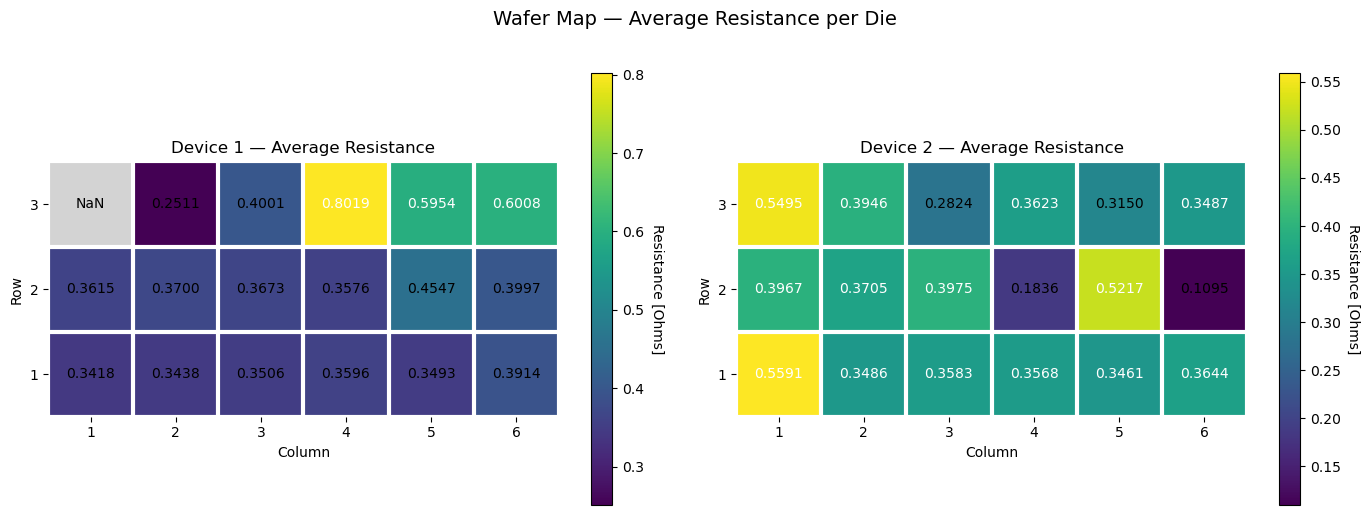

In [3]:
# ---------------------------------------------------------------------------
# Build 2D grids and plot wafer maps
# ---------------------------------------------------------------------------
all_rows = sorted({k[0] for k in resistance_data})
all_cols = sorted({k[1] for k in resistance_data})

n_rows = len(all_rows)
n_cols = len(all_cols)

row_idx = {r: i for i, r in enumerate(all_rows)}
col_idx = {c: i for i, c in enumerate(all_cols)}

grid_dev1 = np.full((n_rows, n_cols), np.nan)
grid_dev2 = np.full((n_rows, n_cols), np.nan)

for (row, col, device), avg_res in resistance_data.items():
    ri = row_idx[row]
    ci = col_idx[col]
    if device == 1:
        grid_dev1[ri, ci] = avg_res
    elif device == 2:
        grid_dev2[ri, ci] = avg_res

cmap = mpl.colormaps.get_cmap('viridis').copy()
cmap.set_bad(color='lightgrey')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1, cbar1 = heatmap(grid_dev1, all_rows, all_cols, ax=ax1,
                     cbarlabel="Resistance [Ohms]", cmap=cmap)
annotate_heatmap(im1, valfmt="{x:.4f}")
ax1.set_title("Device 1 — Average Resistance")

im2, cbar2 = heatmap(grid_dev2, all_rows, all_cols, ax=ax2,
                     cbarlabel="Resistance [Ohms]", cmap=cmap)
annotate_heatmap(im2, valfmt="{x:.4f}")
ax2.set_title("Device 2 — Average Resistance")

fig.suptitle("Wafer Map — Average Resistance per Die", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


In [ ]:
# ---------------------------------------------------------------------------
# Sheet resistance wafer maps  (Rs = R * W/L = R * 12/438)
# ---------------------------------------------------------------------------
CORRECTION = 12 / 438  # W/L factor for 4-pt probe structure (W=12 um, L=438 um)

grid_rs_dev1 = grid_dev1 * CORRECTION
grid_rs_dev2 = grid_dev2 * CORRECTION

cmap_rs = mpl.colormaps.get_cmap('viridis').copy()
cmap_rs.set_bad(color='lightgrey')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1, cbar1 = heatmap(grid_rs_dev1, all_rows, all_cols, ax=ax1,
                     cbarlabel="Sheet Resistance [Ohm/sq]", cmap=cmap_rs)
annotate_heatmap(im1, valfmt="{x:.4f}")
ax1.set_title("Device 1 — Average Sheet Resistance")

im2, cbar2 = heatmap(grid_rs_dev2, all_rows, all_cols, ax=ax2,
                     cbarlabel="Sheet Resistance [Ohm/sq]", cmap=cmap_rs)
annotate_heatmap(im2, valfmt="{x:.4f}")
ax2.set_title("Device 2 — Average Sheet Resistance")

fig.suptitle("Wafer Map — Average Sheet Resistance per Die", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


In [ ]:
# ---------------------------------------------------------------------------
# Histograms of average sheet resistance (Device 1 and Device 2)
# ---------------------------------------------------------------------------
rs_vals_dev1 = grid_rs_dev1[~np.isnan(grid_rs_dev1)].flatten()
rs_vals_dev2 = grid_rs_dev2[~np.isnan(grid_rs_dev2)].flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(rs_vals_dev1, bins='auto', color='steelblue', edgecolor='white')
ax1.set_title("Device 1 — Average Sheet Resistance Distribution")
ax1.set_xlabel("Sheet Resistance [Ohm/sq]")
ax1.set_ylabel("Count")
ax1.tick_params(axis='both', which='both', direction='in')
ax1.axvline(np.mean(rs_vals_dev1), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(rs_vals_dev1):.4f}")
ax1.legend()

ax2.hist(rs_vals_dev2, bins='auto', color='darkorange', edgecolor='white')
ax2.set_title("Device 2 — Average Sheet Resistance Distribution")
ax2.set_xlabel("Sheet Resistance [Ohm/sq]")
ax2.set_ylabel("Count")
ax2.tick_params(axis='both', which='both', direction='in')
ax2.axvline(np.mean(rs_vals_dev2), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(rs_vals_dev2):.4f}")
ax2.legend()

fig.suptitle("Wafer Map — Average Sheet Resistance Histogram", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


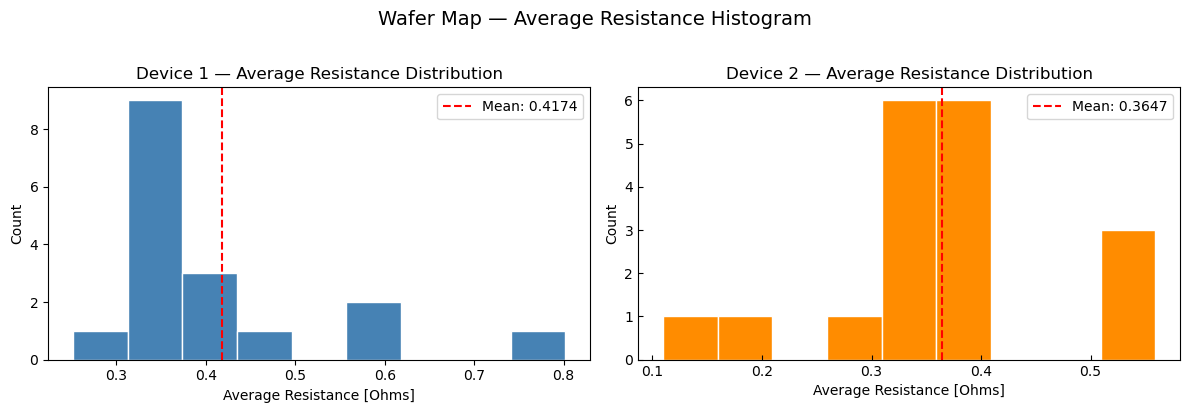

In [ ]:
# ---------------------------------------------------------------------------
# Histograms of average resistance (Device 1 and Device 2)
# ---------------------------------------------------------------------------
vals_dev1 = grid_dev1[~np.isnan(grid_dev1)].flatten()
vals_dev2 = grid_dev2[~np.isnan(grid_dev2)].flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(vals_dev1, bins='auto', color='steelblue', edgecolor='white')
ax1.set_title("Device 1 — Average Resistance Distribution")
ax1.set_xlabel("Average Resistance [Ohms]")
ax1.set_ylabel("Count")
ax1.tick_params(axis='both', which='both', direction='in')
ax1.axvline(np.mean(vals_dev1), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(vals_dev1):.4f}")
ax1.legend()

ax2.hist(vals_dev2, bins='auto', color='darkorange', edgecolor='white')
ax2.set_title("Device 2 — Average Resistance Distribution")
ax2.set_xlabel("Average Resistance [Ohms]")
ax2.set_ylabel("Count")
ax2.tick_params(axis='both', which='both', direction='in')
ax2.axvline(np.mean(vals_dev2), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {np.mean(vals_dev2):.4f}")
ax2.legend()

fig.suptitle("Wafer Map — Average Resistance Histogram", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


C:\Users\Gabe\AppData\Local\Temp\ipykernel_28208\885485681.py:73: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i, j]):


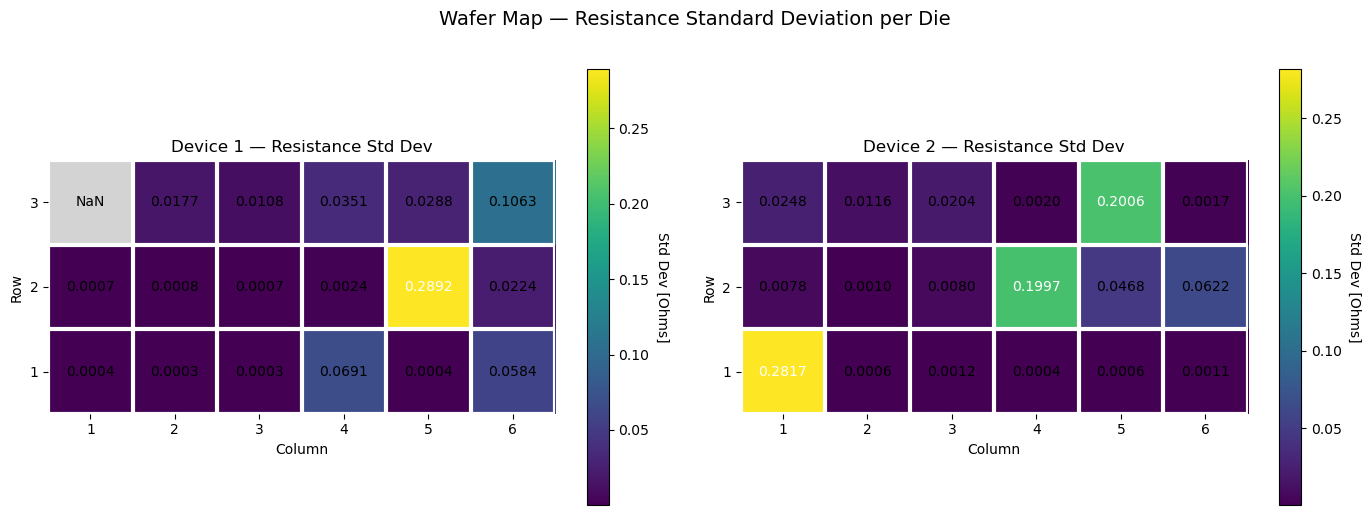

In [5]:
# ---------------------------------------------------------------------------
# Standard deviation wafer maps
# ---------------------------------------------------------------------------
std_dev1 = np.full((n_rows, n_cols), np.nan)
std_dev2 = np.full((n_rows, n_cols), np.nan)

for (row, col, device), std_res in std_data.items():
    ri = row_idx[row]
    ci = col_idx[col]
    if device == 1:
        std_dev1[ri, ci] = std_res
    elif device == 2:
        std_dev2[ri, ci] = std_res

cmap_std = mpl.colormaps.get_cmap('viridis').copy()
cmap_std.set_bad(color='lightgrey')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1, cbar1 = heatmap(std_dev1, all_rows, all_cols, ax=ax1,
                     cbarlabel="Std Dev [Ohms]", cmap=cmap_std)
annotate_heatmap(im1, valfmt="{x:.4f}")
ax1.set_title("Device 1 — Resistance Std Dev")

im2, cbar2 = heatmap(std_dev2, all_rows, all_cols, ax=ax2,
                     cbarlabel="Std Dev [Ohms]", cmap=cmap_std)
annotate_heatmap(im2, valfmt="{x:.4f}")
ax2.set_title("Device 2 — Resistance Std Dev")

fig.suptitle("Wafer Map — Resistance Standard Deviation per Die", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


In [ ]:
# ---------------------------------------------------------------------------
# Sheet resistance standard deviation wafer maps  (std_Rs = std_R * W/L)
# ---------------------------------------------------------------------------
std_rs_dev1 = std_dev1 * CORRECTION
std_rs_dev2 = std_dev2 * CORRECTION

cmap_std_rs = mpl.colormaps.get_cmap('viridis').copy()
cmap_std_rs.set_bad(color='lightgrey')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1, cbar1 = heatmap(std_rs_dev1, all_rows, all_cols, ax=ax1,
                     cbarlabel="Sheet Resistance Std Dev [Ohm/sq]", cmap=cmap_std_rs)
annotate_heatmap(im1, valfmt="{x:.4f}")
ax1.set_title("Device 1 — Sheet Resistance Std Dev")

im2, cbar2 = heatmap(std_rs_dev2, all_rows, all_cols, ax=ax2,
                     cbarlabel="Sheet Resistance Std Dev [Ohm/sq]", cmap=cmap_std_rs)
annotate_heatmap(im2, valfmt="{x:.4f}")
ax2.set_title("Device 2 — Sheet Resistance Std Dev")

fig.suptitle("Wafer Map — Sheet Resistance Standard Deviation per Die", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()
